<a href="https://colab.research.google.com/github/Dindayu-noerja/KKA.Python/blob/main/Analisis_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dindayunoerja","key":"97d0a1c4c32cec86d560f2fa26540511"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s "ecommerce data"

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
cclark/product-item-data                                        eCommerce Item Data                                    140589  2016-08-18 00:32:54.173000          18282        212  0.7058824        
mmohaiminulislam/ecommerce-data-analysis                        ECommerce Data Analysis                              17628279  2024-01-01 02:04:35.787000           9896         69  1                
mkechinov/ecommerce-behavior-data-from-multi-category-store     eCommerce behavior data from multi category store  4606720907  2019-12-09 20:43:39.273000          76174        852  1                
jocke

In [ ]:
!kaggle datasets download -d carrie1/ecommerce-data

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 108MB/s]



In [ ]:
!unzip ecommerce-data.zip

Archive:  ecommerce-data.zip
  inflating: data.csv                


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
os.listdir()

['.config', 'ecommerce-data.zip', 'data.csv', 'kaggle.json', 'sample_data']

In [ ]:
df = pd.read_csv('data.csv', encoding='latin-1')
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [ ]:
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

In [ ]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

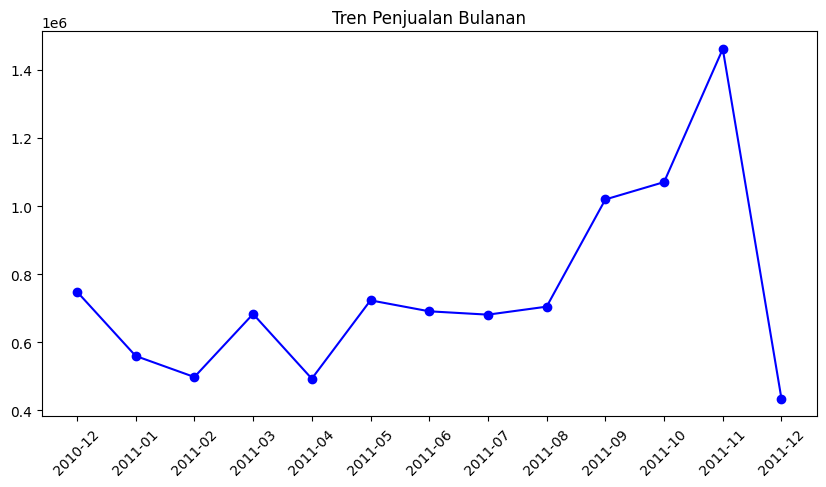

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xticks(rotation=45)
plt.show()

In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Total_Sales', 'Month'],
      dtype='object')


In [ ]:
correlation = df[['Total_Sales', 'Quantity', 'UnitPrice']].corr()

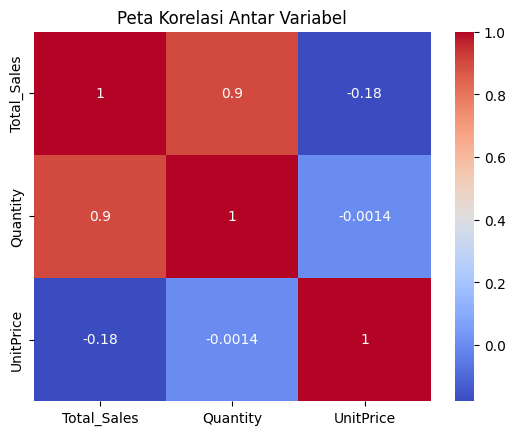

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel')
plt.show()

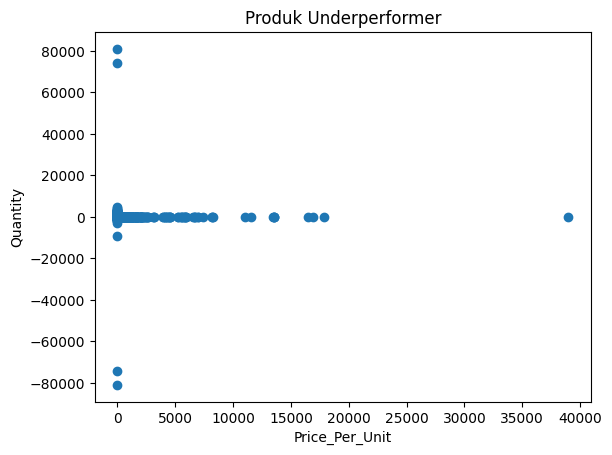

In [ ]:
plt.scatter(df['UnitPrice'], df['Quantity'])
plt.xlabel('Price_Per_Unit')
plt.ylabel('Quantity')
plt.title('Produk Underperformer')
plt.show()

In [ ]:
import datetime as dt

In [ ]:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [ ]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'Total_Sales': 'sum'
})

In [ ]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [ ]:
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,111
12347.0,2,182,4310.00,5,5,5,555
12348.0,75,31,1797.24,2,3,4,234
12349.0,19,73,1757.55,4,4,4,444
12350.0,310,17,334.40,1,2,2,122


In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Total_Sales', 'Month'],
      dtype='object')


In [ ]:
kategori = df.groupby('Description')['Total_Sales'].sum().sort_values()

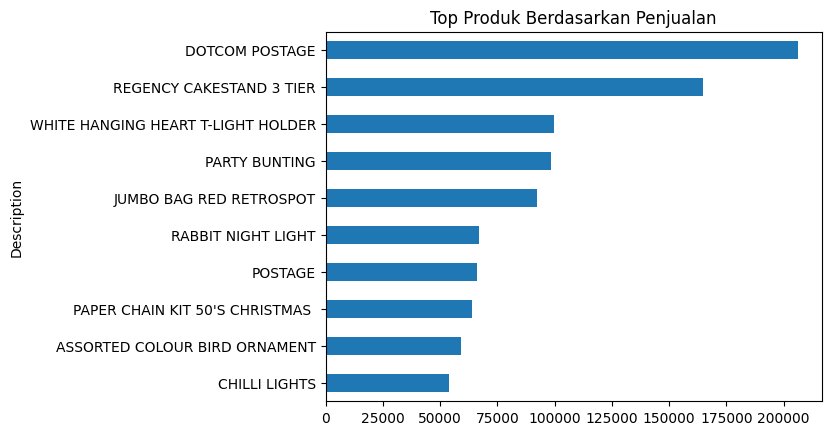

In [ ]:
kategori.tail(10).plot(kind='barh')
plt.title('Top Produk Berdasarkan Penjualan')
plt.show()

In [ ]:
median_price = df['UnitPrice'].median()

In [ ]:
high_price = df[df['UnitPrice'] > median_price]
low_price = df[df['UnitPrice'] <= median_price]

In [ ]:
print("Rata-rata High Price:", high_price['Total_Sales'].mean())
print("Rata-rata Low Price:", low_price['Total_Sales'].mean())

Rata-rata High Price: 21.658094039744938
Rata-rata Low Price: 14.574705986502407


In [ ]:
import os
os.listdir()

['.config', 'sample_data']

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dindayunoerja","key":"97d0a1c4c32cec86d560f2fa26540511"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d carrie1/ecommerce-data

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 93.0MB/s]



In [ ]:
!unzip ecommerce-data.zip

Archive:  ecommerce-data.zip
  inflating: data.csv                


In [ ]:
import os
os.listdir()

['.config', 'ecommerce-data.zip', 'data.csv', 'kaggle.json', 'sample_data']

In [ ]:
import os
os.listdir()

['.config', 'ecommerce-data.zip', 'data.csv', 'kaggle.json', 'sample_data']

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('data.csv')

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa3 in position 79780: invalid start byte